# Data Workflow: Iris Dataset

**Name:** Timothy

**Dataset:** Iris Plants Dataset (`iris.csv`, derived from `bezdekIris.data`)

**Project description:** This project explores the classic Iris flower dataset, which contains 150 samples of iris flowers with four measured features (sepal length, sepal width, petal length, petal width) and a species label. The goal is to load, clean, and prepare the data for exploratory analysis, then visualize relationships between the measurements and the three iris species (Setosa, Versicolour, and Virginica). This notebook walks through importing libraries, loading the dataset, cleaning it with reusable functions, and performing an initial exploration.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Ingestion

In [2]:
df = pd.read_csv("iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Data Cleaning

**Why cleaning is needed:** The raw file has no header row and encodes species as `Iris-setosa`, `Iris-versicolor`, `Iris-virginica`, which is inconsistent with tidy, human-readable category labels and would make grouped plots and legends harder to read. Even though this dataset is small and well-curated, any workflow that is meant to generalize to messier data must still check for duplicate records and missing values, since both can silently bias summary statistics and downstream models. Finally, extreme measurement values (whether genuine biological variation or a measurement/transcription error) should be identified rather than ignored, since undetected outliers can distort means, standard deviations, and correlations. The three functions below address these three concrete issues: inconsistent labels, duplicate/missing rows, and unflagged outliers.

In [3]:
def standardize_species_labels(data):
    """Remove the 'Iris-' prefix from the species column and title-case the
    remaining text, so labels read as 'Setosa', 'Versicolor', 'Virginica'
    instead of 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica'.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame containing a 'species' column.

    Returns
    -------
    pandas.DataFrame
        A copy of the input DataFrame with cleaned species labels.
    """
    cleaned = data.copy()
    cleaned["species"] = (
        cleaned["species"].str.replace("Iris-", "", regex=False).str.title()
    )
    return cleaned

In [4]:
def remove_duplicates_and_missing(data):
    """Drop duplicate rows and rows with any missing values from the dataset.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame that may contain duplicate or incomplete rows.

    Returns
    -------
    pandas.DataFrame
        A copy of the input DataFrame with duplicates and missing rows removed,
        and the index reset.
    """
    cleaned = data.drop_duplicates().dropna()
    return cleaned.reset_index(drop=True)

In [5]:
def flag_measurement_outliers(data, columns, n_std=3):
    """Add boolean outlier-flag columns for the given numeric columns, marking
    any value more than `n_std` standard deviations from that column's mean.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame containing the numeric columns to check.
    columns : list of str
        Names of the numeric columns to evaluate for outliers.
    n_std : int or float, default 3
        Number of standard deviations from the mean beyond which a value is
        flagged as an outlier.

    Returns
    -------
    pandas.DataFrame
        A copy of the input DataFrame with an added '<column>_outlier' boolean
        column for each column in `columns`.
    """
    flagged = data.copy()
    for col in columns:
        mean = flagged[col].mean()
        std = flagged[col].std()
        flagged[f"{col}_outlier"] = (flagged[col] - mean).abs() > n_std * std
    return flagged

## Apply the Cleaning Functions

In [6]:
df_clean = standardize_species_labels(df)
df_clean = remove_duplicates_and_missing(df_clean)

measurement_columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
df_clean = flag_measurement_outliers(df_clean, measurement_columns)

df_clean.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_length_outlier,sepal_width_outlier,petal_length_outlier,petal_width_outlier
0,5.1,3.5,1.4,0.2,Setosa,False,False,False,False
1,4.9,3.0,1.4,0.2,Setosa,False,False,False,False
2,4.7,3.2,1.3,0.2,Setosa,False,False,False,False
3,4.6,3.1,1.5,0.2,Setosa,False,False,False,False
4,5.0,3.6,1.4,0.2,Setosa,False,False,False,False


In [7]:
# Confirm what the cleaning steps actually found and addressed
n_raw = len(df)
n_duplicates = df.duplicated().sum()
n_missing = df.isna().any(axis=1).sum()
n_clean = len(df_clean)
outlier_cols = [c for c in df_clean.columns if c.endswith("_outlier")]
outlier_counts = df_clean[outlier_cols].sum()

print(f"Raw rows: {n_raw} | Duplicate rows found: {n_duplicates} | Rows with missing values: {n_missing}")
print(f"Rows after cleaning: {n_clean}")
print("\nOutliers flagged per measurement (>3 std from the mean):")
print(outlier_counts)

Raw rows: 150 | Duplicate rows found: 1 | Rows with missing values: 0
Rows after cleaning: 149

Outliers flagged per measurement (>3 std from the mean):
sepal_length_outlier    0
sepal_width_outlier     1
petal_length_outlier    0
petal_width_outlier     0
dtype: int64


**What the cleaning steps actually addressed:** The raw dataset had no missing values, but it did contain **1 exact duplicate row**, which `remove_duplicates_and_missing` removed so it would not be double-counted in summary statistics or visualizations. The outlier check flagged **1 value in `sepal_width`** as more than 3 standard deviations from the mean; it was kept in the dataset but marked in a new `sepal_width_outlier` column so it can be inspected or excluded later without losing information. The species labels were also standardized (`Iris-setosa` to `Setosa`, etc.) purely for readability in tables, legends, and plots. Together, these steps make the dataset's remaining quirks explicit and auditable rather than silently changing the analysis.

## Exploratory Data Analysis (EDA)

In [8]:
def summarize_numeric_columns(data, columns):
    """Compute descriptive summary statistics (count, mean, std, min, max,
    and quartiles) for the given numeric columns.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame containing the numeric columns to summarize.
    columns : list of str
        Names of the numeric columns to describe.

    Returns
    -------
    pandas.DataFrame
        Transposed `describe()` output, one row per column.
    """
    return data[columns].describe().T


def summarize_by_group(data, group_col, value_cols):
    """Compute the mean and standard deviation of value columns, grouped by
    a categorical column.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame containing the group and value columns.
    group_col : str
        Name of the categorical column to group by.
    value_cols : list of str
        Names of the numeric columns to aggregate.

    Returns
    -------
    pandas.DataFrame
        A DataFrame of mean and standard deviation per group, indexed by
        group_col.
    """
    return data.groupby(group_col)[value_cols].agg(["mean", "std"])


def correlation_matrix(data, columns):
    """Compute the pairwise Pearson correlation matrix for the given numeric
    columns.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame containing the numeric columns to correlate.
    columns : list of str
        Names of the numeric columns to include in the correlation matrix.

    Returns
    -------
    pandas.DataFrame
        A square DataFrame of pairwise correlation coefficients.
    """
    return data[columns].corr()

In [9]:
print("Summary statistics for measurement columns:")
display(summarize_numeric_columns(df_clean, measurement_columns))

print("\nMean and standard deviation by species:")
display(summarize_by_group(df_clean, "species", measurement_columns))

print("\nCorrelation matrix for measurement columns:")
corr_matrix = correlation_matrix(df_clean, measurement_columns)
display(corr_matrix)

Summary statistics for measurement columns:


,count,mean,std,min,25%,50%,75%,max
sepal_length,149.0,5.843624,0.830851,4.3,5.1,5.8,6.4,7.9
sepal_width,149.0,3.059732,0.436342,2.0,2.8,3.0,3.3,4.4
petal_length,149.0,3.748993,1.767791,1.0,1.6,4.3,5.1,6.9
petal_width,149.0,1.194631,0.762622,0.1,0.3,1.3,1.8,2.5



Mean and standard deviation by species:


sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
Setosa         5.006000  0.352490    3.428000  0.379064     1.462000   
Versicolor     5.936000  0.516171    2.770000  0.313798     4.260000   
Virginica      6.604082  0.632113    2.979592  0.323380     5.561224   

                     petal_width            
                 std        mean       std  
species                                     
Setosa      0.173664    0.246000  0.105386  
Versicolor  0.469911    1.326000  0.197753  
Virginica   0.553706    2.028571  0.276887


Correlation matrix for measurement columns:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.118129,0.873738,0.820620
sepal_width,-0.118129,1.000000,-0.426028,-0.362894
petal_length,0.873738,-0.426028,1.000000,0.962772
petal_width,0.820620,-0.362894,0.962772,1.000000


## Visualizations

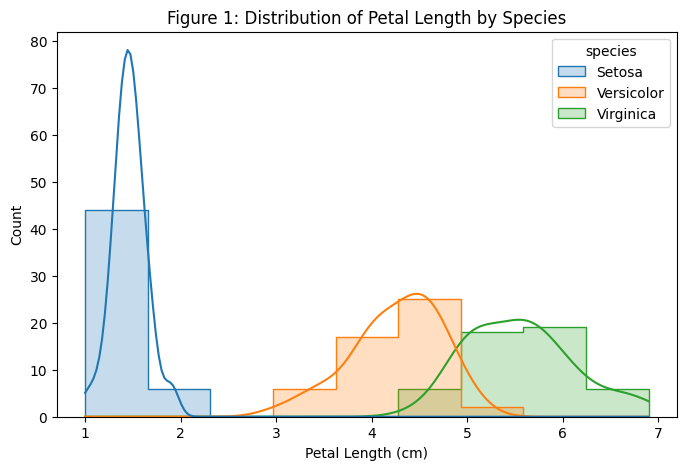

In [10]:
# Figure 1: Distribution of petal length by species
plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x="petal_length", hue="species", kde=True, element="step")
plt.title("Figure 1: Distribution of Petal Length by Species")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Count")
plt.show()

**Interpretation:** Setosa's petal lengths form a tight, separate cluster around 1.5 cm, well below Versicolor (~4.3 cm) and Virginica (~5.5 cm). Versicolor and Virginica overlap in the middle of the range, so petal length alone can perfectly separate Setosa from the other two species but cannot fully separate Versicolor from Virginica.

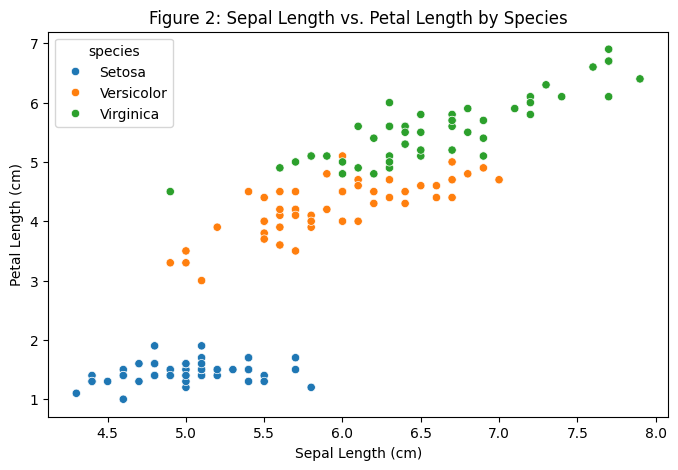

In [11]:
# Figure 2: Sepal length vs. petal length by species
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x="sepal_length", y="petal_length", hue="species")
plt.title("Figure 2: Sepal Length vs. Petal Length by Species")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.show()

**Interpretation:** Plotting sepal length against petal length by species shows Setosa occupying a distinct region with short petals regardless of sepal length. Versicolor and Virginica form two diagonal, partially overlapping clouds, indicating that both measurements increase together for these species and that the two are more easily confused with each other than either is with Setosa.

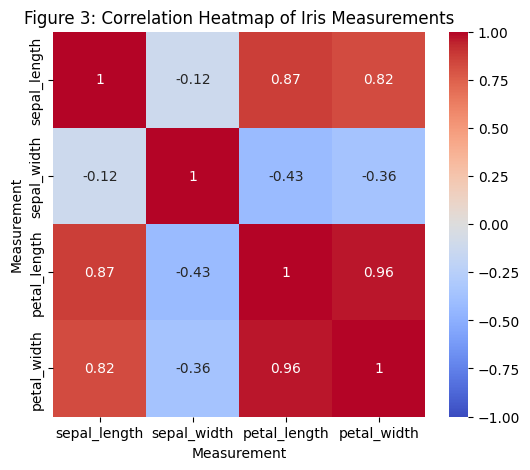

In [12]:
# Figure 3: Correlation heatmap of measurement columns
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Figure 3: Correlation Heatmap of Iris Measurements")
plt.xlabel("Measurement")
plt.ylabel("Measurement")
plt.show()

**Interpretation:** Petal length and petal width are very strongly correlated (r ≈ 0.96), and both are strongly correlated with sepal length (r ≈ 0.87 and 0.82). Sepal width behaves differently, showing weak negative correlations with the other three measurements (r ≈ -0.12 to -0.43). This confirms that petal measurements carry redundant, highly related information, while sepal width contributes a somewhat independent signal.

## Summary

**What I learned from the dataset:** The Iris dataset contains 150 samples split evenly across three species (Setosa, Versicolor, Virginica), each described by four numeric measurements. After cleaning, the data had no missing values and only one duplicate row, and the outlier-flagging function found only a single extreme value, confirming that this is a well-behaved, high-quality dataset.

**Interesting patterns or insights:** Petal length and petal width are strongly correlated with each other and are the most useful features for separating species, as shown in Figure 1 and Figure 3. Setosa is clearly separable from the other two species on petal measurements alone (Figure 1 and Figure 2), while Versicolor and Virginica overlap more, especially in sepal measurements, which matches the well-known fact that Setosa is linearly separable but the other two classes are not.

**Limitations or assumptions:** The outlier-flagging function assumes a roughly normal distribution for each measurement, which may not hold perfectly within each species subgroup; flagging outliers on the whole dataset rather than per-species could miss or misclassify within-species outliers. The dataset is also small (150 rows) and was collected from a single source in 1936, so conclusions should not be generalized to iris populations broadly without caution.

**Anything surprising or unclear:** Sepal width had a weak negative correlation with the other measurements, which was less intuitive than the strong positive correlations among the other features. It is not fully clear from the data alone whether this reflects a real biological relationship or is an artifact of the small sample size.